MARKET BASKET ANALYSIS ON GROCERIES DATASET

In [5]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.4 MB 812.7 kB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.4 MB 2.5 MB/s eta 0:00:01
   ----------------- ---------------------- 0.6/1.4 MB 3.3 MB/s eta 0:00:01
   ---------------------- ----------------- 0.8/1.4 MB 3.7 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 3.9 MB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB 5.7 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/8.9 MB 6.3 MB/s eta 0:00:02
   --- ------------------------------------ 0.9/8.9 MB 6.0 MB/s eta 0:00:02
   ----- ----------------------

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

In [7]:
data = pd.read_csv(r'C:\Users\sekpu\Desktop\Teks 2024\All_data_sets\Groceries_dataset.csv')
data.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [10]:
data.describe()

,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


In [11]:
data.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

SHAPE AND BASIC INFORMATION OF DATASET

In [15]:
print("Shape:", data.shape)
print("\nColumns:", data.columns)  
print("\nNull values:\n", data.isnull().sum())
print("\nData  types:\n", data.dtypes)

Shape: (38765, 3)

Columns: Index(['Member_number', 'Date', 'itemDescription'], dtype='object')

Null values:
 Member_number      0
Date               0
itemDescription    0
dtype: int64

Data  types:
 Member_number       int64
Date               object
itemDescription    object
dtype: object


In [17]:
print("Unique members:", data['Member_number'].nunique())
print("Unique items:", data['itemDescription'].nunique())

Unique members: 3898
Unique items: 167


TOP 20 FREQUENTLY PURCHASED PRODUCTS

In [20]:
item_counts = data['itemDescription'].value_counts().head(20)
item_counts

itemDescription
whole milk            2502
other vegetables      1898
rolls/buns            1716
soda                  1514
yogurt                1334
root vegetables       1071
tropical fruit        1032
bottled water          933
sausage                924
citrus fruit           812
pastry                 785
pip fruit              744
shopping bags          731
canned beer            717
bottled beer           687
whipped/sour cream     662
newspapers             596
frankfurter            580
brown bread            571
pork                   566
Name: count, dtype: int64

TOP 20 ITEMS (PLOT)

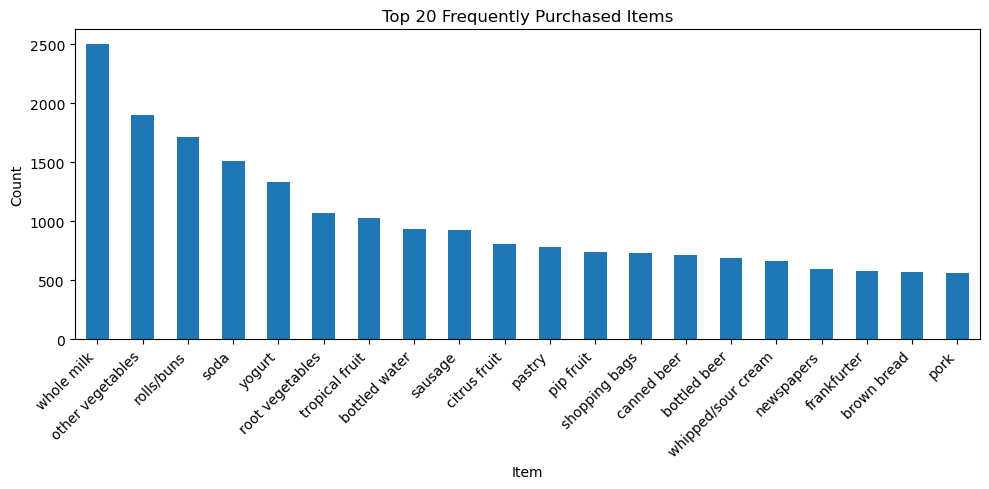

In [27]:
plt.figure(figsize=(10,5))
item_counts.plot(kind='bar')
plt.title('Top 20 Frequently Purchased Items')
plt.xlabel('Item')
plt.ylabel('Count')
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()
plt.show()

In [28]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')

data['TransactionID'] = data['Member_number'].astype(str) + "_" + data['Date'].dt.strftime("%Y-%m-%d")

data[['Member_number', 'Date', 'itemDescription', 'TransactionID']].head()

,Member_number,Date,itemDescription,TransactionID
0,1808,2015-07-21,tropical fruit,1808_2015-07-21
1,2552,2015-01-05,whole milk,2552_2015-01-05
2,2300,2015-09-19,pip fruit,2300_2015-09-19
3,1187,2015-12-12,other vegetables,1187_2015-12-12
4,3037,2015-02-01,whole milk,3037_2015-02-01


In [29]:
items_per_tcn = data.groupby('TransactionID')['itemDescription'].nunique()
print("Average items per transaction", items_per_tcn.mean())
print("Min items per transaction:", items_per_tcn.min())
print("Max items per transaction:", items_per_tcn.max())

Average items per transaction 2.539998663369645
Min items per transaction: 1
Max items per transaction: 10


In [30]:
sample_baskets = data.groupby('TransactionID')['itemDescription'].apply(list).head(5)
sample_baskets

TransactionID
1000_2014-06-24                    [whole milk, pastry, salty snack]
1000_2015-03-15    [sausage, whole milk, semi-finished bread, yog...
1000_2015-05-27                           [soda, pickled vegetables]
1000_2015-07-24                       [canned beer, misc. beverages]
1000_2015-11-25                          [sausage, hygiene articles]
Name: itemDescription, dtype: object

PIVOT TABLE

In [32]:
basket = (data
          .groupby(['TransactionID', 'itemDescription'])['itemDescription']
          .count()
          .unstack()
          .fillna(0))

basket = (basket>0).astype(int)
basket.head()

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
TransactionID,,,,,,,,,,,,,,,,,,,,,
1000_2014-06-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1000_2015-03-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1000_2015-05-27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1000_2015-07-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1000_2015-11-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
item_support = basket.mean(axis=0)
rare_items = item_support[item_support < 0.005].index 
basket_reduced = basket.drop(columns=rare_items)

print("Original items:", basket.shape[1])
print("After dropping rare items:", basket_reduced.shape[1])

Original items: 167
After dropping rare items: 89


In [34]:
basket_apriori = basket_reduced.copy()

In [50]:
min_support_value = 0.003

frequent_itemsets = apriori(
    basket_apriori,
    min_support=min_support_value,
    use_colnames=True
)

print("Number of frequent itemsets:", len(frequent_itemsets))
frequent_itemsets.head()

C:\Users\sekpu\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 194


,support,itemsets
0,0.021386,(UHT-milk)
1,0.008087,(baking powder)
2,0.033950,(beef)
3,0.021787,(berries)
4,0.016574,(beverages)


In [51]:
frequent_itemsets.sort_values('support', ascending = False).head(10)

,support,itemsets
87,0.157923,(whole milk)
53,0.122101,(other vegetables)
66,0.110005,(rolls/buns)
75,0.097106,(soda)
88,0.085879,(yogurt)
67,0.069572,(root vegetables)
81,0.067767,(tropical fruit)
6,0.060683,(bottled water)
70,0.060349,(sausage)
19,0.053131,(citrus fruit)


ASSOCIATION RULES

In [52]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0
)

print("Number of rules:", len(rules))
rules.head()

rules_sorted = (rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
                .sort_values('lift', ascending=False))

rules_sorted.head(10)

Number of rules: 16


,antecedents,consequents,support,confidence,lift
0,(sausage),(bottled beer),0.003342,0.055371,1.222000
1,(bottled beer),(sausage),0.003342,0.073746,1.222000
4,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
5,(other vegetables),(frankfurter),0.005146,0.042146,1.116150
14,(yogurt),(sausage),0.005748,0.066926,1.108986
15,(sausage),(yogurt),0.005748,0.095238,1.108986
8,(sausage),(pastry),0.003208,0.053156,1.027617
9,(pastry),(sausage),0.003208,0.062016,1.027617
12,(soda),(sausage),0.005948,0.061253,1.014975
13,(sausage),(soda),0.005948,0.098560,1.014975


In [53]:
def frozenset_to_str(fs):
    return ", ".join(list(fs))

rules_sorted['antecedents_str'] = rules_sorted['antecedents'].apply(frozenset_to_str)
rules_sorted['consequents_str'] = rules_sorted['consequents'].apply(frozenset_to_str)

rules_sorted.head(10)

,antecedents,consequents,support,confidence,lift,antecedents_str,consequents_str
0,(sausage),(bottled beer),0.003342,0.055371,1.222000,sausage,bottled beer
1,(bottled beer),(sausage),0.003342,0.073746,1.222000,bottled beer,sausage
4,(frankfurter),(other vegetables),0.005146,0.136283,1.116150,frankfurter,other vegetables
5,(other vegetables),(frankfurter),0.005146,0.042146,1.116150,other vegetables,frankfurter
14,(yogurt),(sausage),0.005748,0.066926,1.108986,yogurt,sausage
15,(sausage),(yogurt),0.005748,0.095238,1.108986,sausage,yogurt
8,(sausage),(pastry),0.003208,0.053156,1.027617,sausage,pastry
9,(pastry),(sausage),0.003208,0.062016,1.027617,pastry,sausage
12,(soda),(sausage),0.005948,0.061253,1.014975,soda,sausage
13,(sausage),(soda),0.005948,0.098560,1.014975,sausage,soda


HEATMAP 

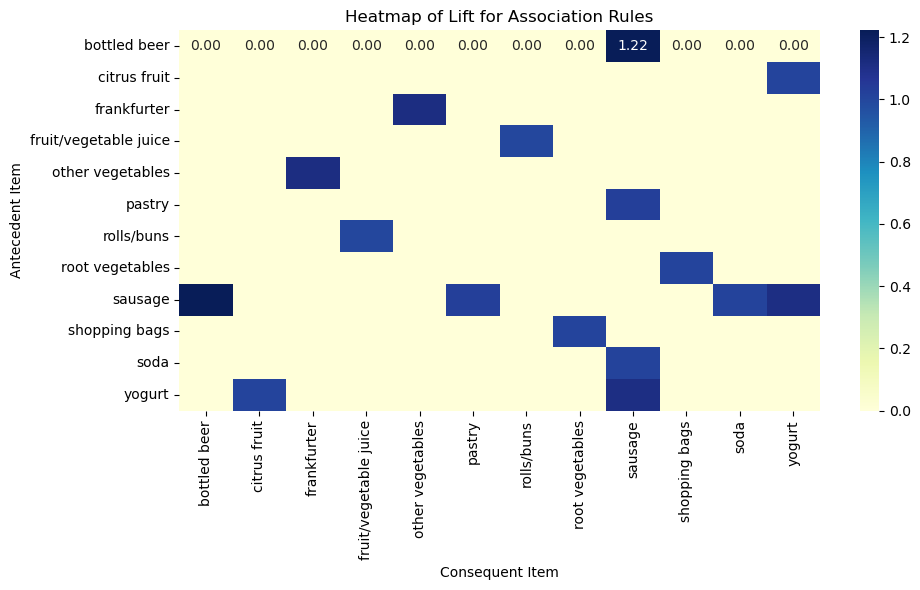

In [55]:
if rules.empty:
    print("No association rules found. Try lowering minimum support further.")
else:
    N = min(20, len(rules_sorted))
    heatmap_rules = rules_sorted.head(N)

    lift_matrix = heatmap_rules.pivot_table(
        index='antecedents_str',
        columns='consequents_str',
        values='lift',
        aggfunc='mean'
    )

    if lift_matrix.shape[0] == 0 or lift_matrix.shape[1] == 0:
        print("Not enough rules to create a heatmap.")
    else:
        lift_matrix = lift_matrix.fillna(0)
        plt.figure(figsize=(10, 6))
        sns.heatmap(lift_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
        plt.title("Heatmap of Lift for Association Rules")
        plt.xlabel("Consequent Item")
        plt.ylabel("Antecedent Item")
        plt.tight_layout()
        plt.show()


CONCLUSION :

This market basket analysis revealed significant co-purchasing trends among grocery items through the use of association rules and lift scores. The heatmap illustrated item combinations that are found together much more frequently than anticipated, suggesting robust associative behavior. These insights offer valuable business intelligence for product placement, promotional bundles, and cross-selling strategies, showcasing how transactional data can be transformed into actionable retail decisions.

Key Insights:

• Certain items are often bought together, demonstrating strong lift values
• Sausage, yogurt, root vegetables, and shopping bags commonly appear in associated pairs
• High lift pairs present dependable opportunities for combo offers and promotions
• Decisions regarding product placement can be enhanced based on identified buying relationships
• The patterns facilitate targeted marketing, inventory optimization, and recommendation systems